# K-means практика


In [23]:
# Установка зависимостей
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd

In [25]:
# Загрузка датасета
df = pd.read_csv("https://code.s3.yandex.net/datasets/ds_s18t2_customer_segmentation.csv")

df.head()

,id,year_birth,education,marital_status,income,kids,date_first_purchase,days_since_last_purchase,num_purchases_at_shop,num_web_purchases,avg_purchase_sum
0,486,1993,Graduation,Married,33069.1,0,15-11-2012,113,1,1,36.9
1,6690,1971,Basic,Widow,98707.1,2,21-08-2013,19,10,4,283.2
2,7101,1995,Graduation,Married,34859.8,0,31-07-2012,120,2,1,31.2
3,1357,1984,Master,Single,69317.6,1,30-06-2013,61,3,8,114.1
4,10785,1998,Basic,Divorced,122592.0,5,08-04-2014,178,2,2,52.1


In [27]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from matplotlib import pyplot as plt
from sklearn.preprocessing import OneHotEncoder

df = pd.read_csv("https://code.s3.yandex.net/datasets/ds_s18t2_customer_segmentation.csv")

df = df.drop(columns=['id', 'date_first_purchase'])   # удалите столбцы id и date_first_purchase
cat_cols = df.select_dtypes('str').columns    # создайте список категориальных признаков
num_cols = df.select_dtypes('number').columns   # создайте список числовых признаков

cat_pipeline = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown="ignore"))
])  # создайте пайплайн для работы с категориальными признаками

print(cat_pipeline)

Pipeline(steps=[('ohe', OneHotEncoder(handle_unknown='ignore'))])


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ('ohe', StandardScaler())
])

preprocess = ColumnTransformer(
	transformers=[
		('cat', cat_pipeline, cat_cols),
        ('num', num_pipeline, num_cols)
	]
)

print(preprocess)

ColumnTransformer(transformers=[('cat',
                                 Pipeline(steps=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['education', 'marital_status'], dtype='str')),
                                ('num',
                                 Pipeline(steps=[('ohe', StandardScaler())]),
                                 Index(['year_birth', 'income', 'kids', 'days_since_last_purchase',
       'num_purchases_at_shop', 'num_web_purchases', 'avg_purchase_sum'],
      dtype='str'))])


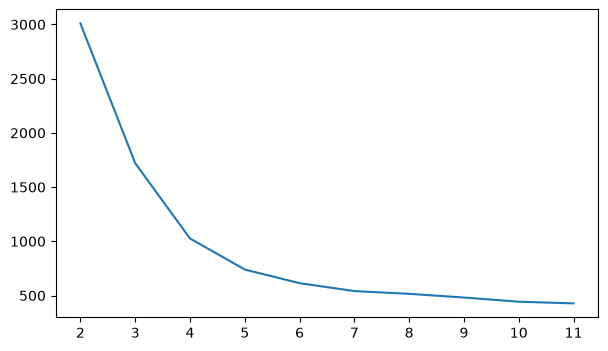

In [35]:
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

ks = list(range(2, 12))
wcss = []

for k in ks:
    pipe = Pipeline([
        ('preprocess', preprocess),
        ('kmeans', KMeans(
            n_clusters = k,
            random_state=42,
            init="k-means++"
        ))
    ])

    pipe.fit(df)
    inertia = pipe.named_steps["kmeans"].inertia_ 
    wcss.append(inertia)

plt.figure(figsize=(7, 4))
plt.plot(ks, wcss)
plt.xticks(ks)
plt.show()

In [37]:
from sklearn.metrics import pairwise_distances, silhouette_score

model = Pipeline([
    ("preprocess", preprocess),
    ("kmeans", KMeans(n_clusters=4, init="k-means++", random_state=42))
])
model.fit(df)

wcss = model.named_steps["kmeans"].inertia_

# посчитаем межкластерное расстояние
centers = model.named_steps["kmeans"].cluster_centers_
d = pairwise_distances(centers)
mask = ~np.eye(d.shape[0], dtype=bool)   # True всюду, кроме диагонали
inter_min = d[mask].min()
inter_mean = d[mask].mean()

# посчитаем силуэтный коэффициент
X = preprocess.fit_transform(df)
labels = model.named_steps["kmeans"].labels_
sil_score = silhouette_score(X, labels)

print(f"WCSS: {wcss:.2f}")
print(f"Минимальное межкластерное расстояние: {inter_min:.2f}")
print(f"Среднее межкластерное расстояние: {inter_mean:.2f}")
print(f"Силуэтный коэффициент: {sil_score:.2f}")

WCSS: 1026.25
Минимальное межкластерное расстояние: 2.96
Среднее межкластерное расстояние: 4.20
Силуэтный коэффициент: 0.71
